# NV Center DOS Analysis
Load and plot DOS data from JSON output files.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Configure ──────────────────────────────────────────────
results_dir = Path('/Users/famkepotze/Desktop/3S/NV-center-3S/QuantumEspresso/results/dos')
sizes = ['1x1x1', '2x2x2', '3x3x3']  # add/remove as needed


In [2]:
# ── Load all available DOS files ───────────────────────────
dos_data = {}

for size in sizes:
    path = results_dir / f'NV_{size}.json'
    if path.exists():
        with open(path) as f:
            d = json.load(f)
        dos_data[size] = {
            'energy': np.array(d['energy_eV']),
            'dos':    np.array(d['dos'])
        }
        print(f'Loaded {size}: {len(d["energy_eV"])} points')
    else:
        print(f'Not found: {path}')


Loaded 1x1x1: 2001 points
Not found: /Users/famkepotze/Desktop/3S/NV-center-3S/QuantumEspresso/results/dos/NV_2x2x2.json
Not found: /Users/famkepotze/Desktop/3S/NV-center-3S/QuantumEspresso/results/dos/NV_3x3x3.json


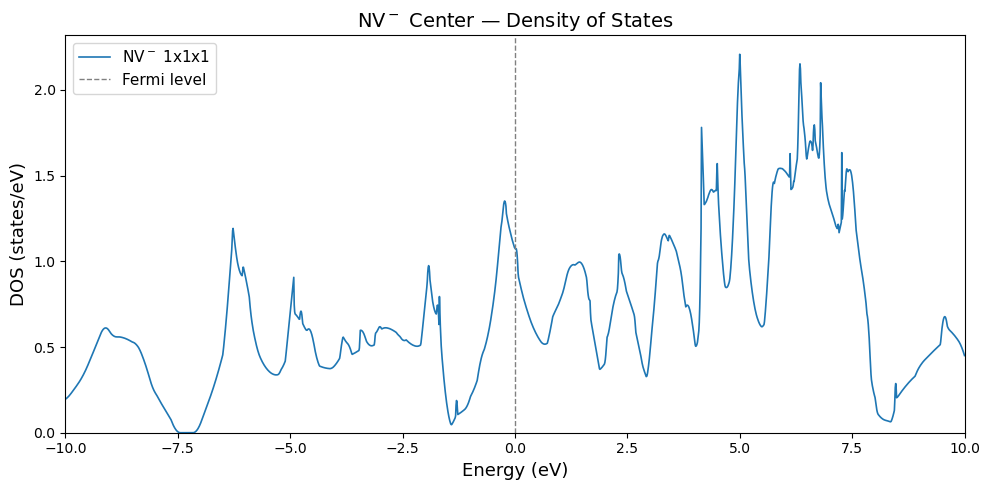

In [3]:
# ── Plot all sizes on one figure ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for size, d in dos_data.items():
    ax.plot(d['energy'], d['dos'], label=f'NV$^-$ {size}', linewidth=1.2)

ax.axvline(0, color='gray', linestyle='--', linewidth=1, label='Fermi level')
ax.set_xlabel('Energy (eV)', fontsize=13)
ax.set_ylabel('DOS (states/eV)', fontsize=13)
ax.set_title('NV$^-$ Center — Density of States', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(-10, 10)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(results_dir / 'DOS_comparison.png', dpi=150)
plt.show()


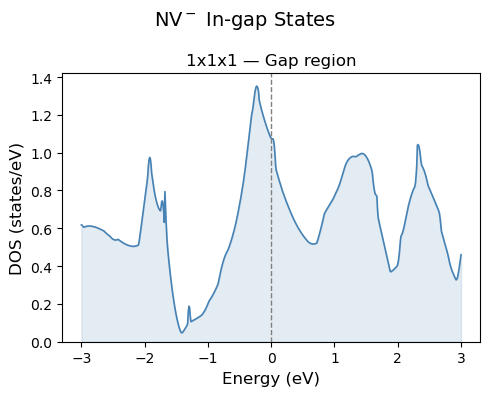

In [4]:
# ── Zoom into gap region ────────────────────────────────────
fig, axes = plt.subplots(1, len(dos_data), figsize=(5 * len(dos_data), 4), sharey=False)
if len(dos_data) == 1:
    axes = [axes]

for ax, (size, d) in zip(axes, dos_data.items()):
    mask = (d['energy'] >= -3) & (d['energy'] <= 3)
    ax.plot(d['energy'][mask], d['dos'][mask], color='steelblue', linewidth=1.2)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.fill_between(d['energy'][mask], d['dos'][mask], alpha=0.15, color='steelblue')
    ax.set_xlabel('Energy (eV)', fontsize=12)
    ax.set_ylabel('DOS (states/eV)', fontsize=12)
    ax.set_title(f'{size} — Gap region', fontsize=12)
    ax.set_ylim(bottom=0)

plt.suptitle('NV$^-$ In-gap States', fontsize=14)
plt.tight_layout()
plt.savefig(results_dir / 'DOS_gap_zoom.png', dpi=150)
plt.show()


In [5]:
# ── Quick stats ─────────────────────────────────────────────
for size, d in dos_data.items():
    e, dos = d['energy'], d['dos']
    # find gap: region where DOS < threshold near Fermi level
    gap_mask = (e >= -2) & (e <= 2)
    gap_min  = dos[gap_mask].min()
    gap_min_e = e[gap_mask][dos[gap_mask].argmin()]
    print(f'{size}:')
    print(f'  DOS min near Fermi: {gap_min:.4f} at {gap_min_e:.2f} eV')
    print(f'  DOS at Fermi (E=0): {np.interp(0, e, dos):.4f} states/eV')
    print()


1x1x1:
  DOS min near Fermi: 0.0470 at -1.41 eV
  DOS at Fermi (E=0): 1.0760 states/eV

